In [277]:
# Import libraries and load the raw dataset into a DataFrame.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
df=pd.read_csv("Accidental_Drug_Related_Deaths.csv")

In [278]:
# Quick check of dataset dimensions: (rows, columns).
df.shape

(11981, 48)

In [279]:
# Profile missing values and identify columns with more than 60% missing data.
missing_counts = df.isna().sum()
missing_percentage = (df.isna().mean()* 100).sort_values(ascending=False)
cols_over_60 = missing_percentage[missing_percentage > 60]

# Data Preprocessing

First we will standardize all y/n to 1's and 0's which is the data format that can be used in machine learning and analysis

In [280]:
# Build drug indicator columns and convert "Y" flags into binary 1/0 values.
drug_columns = [
    col for col in df.columns
    if col not in [
        "Date", "Date Type", "Age", "Sex", "Race", "Ethnicity",
        "Residence City", "Residence County", "Residence State","Injury City", "Injury County", "Injury State","Death City", "Death County", "Death State",
        "Injury Place", "Description of Injury","Location", "Location if Other","Cause of Death", "Manner of Death",
        "Other Significant Conditions","ResidenceCityGeo", "InjuryCityGeo", "DeathCityGeo",
    ]
]

df_clean=pd.read_csv("Accidental_Drug_Related_Deaths.csv")

for col in drug_columns:
    df_clean[col] = df_clean[col].apply(lambda x: 1 if x == "Y" else 0)


Then we will run a variability report

In [281]:
# Generate a variability report to guide keep/drop/transform feature decisions.
# Heuristics
DOMINANCE_DROP_THRESHOLD = 0.995   # >= 99.5% same value among non-null -> drop as feature (usually)
HIGH_MISSING_THRESHOLD   = 0.90    # >= 90% missing -> usually drop/transform
LOW_UNIQUE_THRESHOLD     = 1       # 1 unique value among non-null -> constant


rows = []
n = len(df_clean)

for col in df_clean.columns:
    s = df_clean[col]

    non_null = int(s.notna().sum())
    missing_pct = float((n - non_null) / n) if n else np.nan

    # Unique values among non-null
    non_null_s = s.dropna()
    unique_non_null = int(non_null_s.nunique()) if non_null > 0 else 0

    # Most common value among non-null
    if non_null > 0:
        vc = non_null_s.value_counts(dropna=True)
        top_value = vc.index[0]
        top_count = int(vc.iloc[0])
        top_pct_of_non_null = float(top_count / non_null) if non_null else np.nan
    else:
        top_value = np.nan
        top_count = 0
        top_pct_of_non_null = np.nan

    # Recommendation logic (simple + explainable)
    recommendation = "Keep"
    reason = []

    if non_null == 0:
        recommendation = "Drop-as-feature"
        reason.append("All missing")
    else:
        if missing_pct >= HIGH_MISSING_THRESHOLD:
            recommendation = "Transform/Review"
            reason.append(f"High missingness ({missing_pct:.1%})")

        if unique_non_null <= LOW_UNIQUE_THRESHOLD:
            recommendation = "Drop-as-feature"
            reason.append("No variability (constant)")

        # Dominance check (near-constant)
        if pd.notna(top_pct_of_non_null) and top_pct_of_non_null >= DOMINANCE_DROP_THRESHOLD:
            # If it's already flagged as high missing, keep as Transform/Review,
            # otherwise drop as feature.
            if recommendation != "Transform/Review":
                recommendation = "Drop-as-feature"
            reason.append(f"Low variability (top value dominates {top_pct_of_non_null:.1%})")

    rows.append({
        "column": col,
        "non_null": non_null,
        "missing_%": round(missing_pct * 100, 2) if pd.notna(missing_pct) else np.nan,
        "unique_non_null": unique_non_null,
        "most_occuring_value": top_value,
        "most_occuring_count": top_count,
        "top_%_of_non_null": round(top_pct_of_non_null * 100, 2) if pd.notna(top_pct_of_non_null) else np.nan,
        "recommendation": recommendation,
        "reason": "; ".join(reason) if reason else ""
    })

report = pd.DataFrame(rows)

# Sort to surface "worst offenders" first (high missing, then high dominance)
report = report.sort_values(
    by=["missing_%", "top_%_of_non_null", "unique_non_null"],
    ascending=[False, False, True]
).reset_index(drop=True)

report.to_csv("F:/0_TAYLORS/Y2S1/DM/assg1/variability_report.csv", index=False)

Based on the report , I have decided to drop a few columns. This is because these columns provide little data as a feature , due to either high amounts of missingness , or low variability(indicated by unique_non_null)

In [282]:
# Drop columns that are not needed for the cleaned analysis dataset.
df_clean.drop(columns=["Manner of Death","Other","Other Significant Conditions "], inplace=True)
df_clean.drop(columns=["Residence State","Injury State","Death State"], inplace=True)


Next , we fill all missing values with 0 first , then for categorical attributes , we replace 0 with unknown instead

In [283]:
# Fill missing values and standardize selected categorical placeholders as "Unknown".
df_clean.fillna(0, inplace=True)

cols_with_zero_placeholders = [
    "Sex", "Race", "Ethnicity", "Description of Injury",
    "Residence County", "Residence City" ,"Injury County", "Injury City", "Death County",
    "Injury Place", "Location", "Location if Other",
    "Other Significant Conditions", "Death City"
]

for c in cols_with_zero_placeholders:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].replace(["0", 0], np.nan)
        df_clean[c] = df_clean[c].fillna("Unknown")


After that , we now standardise category labels that are duplicates

In [284]:
# Normalize race text values so equivalent labels are grouped consistently.
df_clean["Race"] = df_clean["Race"].astype(str)
df_clean["Race"] = df_clean["Race"].str.replace(r"^\s*black\s*$", "Black or African American", case=False, regex=True)
df_clean["Race"] = df_clean["Race"].str.replace(r"^\s*african\s+american\s*$", "Black or African American", case=False, regex=True)
df_clean["Race"] = df_clean["Race"].str.replace(r"^\s*caucasian\s*$", "White", case=False, regex=True)
df_clean["Race"] = df_clean["Race"].str.replace(r"^\s*white\s*$", "White", case=False, regex=True)
df_clean["Race"] = df_clean["Race"].str.replace(r"^\s*other\s+asian\s*$", "Asian", case=False, regex=True)
df_clean["Race"] = df_clean["Race"].str.replace(r"^\s*Asian\s+Indian\s*$", "Asian", case=False, regex=True)
df_clean["Race"] = df_clean["Race"].str.replace(r"^\s*Asian,\s+Other\s*$", "Asian", case=False, regex=True)

Then we also work on converting the date which is in plain text , to a proper datetime data type

In [285]:
# Parse dates and derive calendar features for temporal trend analysis.
if "Date" in df.columns:
    df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")  # handles mm/dd/yyyy too
    df_clean["Year"] = df_clean["Date"].dt.year
    df_clean["Month"] = df_clean["Date"].dt.month
    df_clean["Quarter"] = df_clean["Date"].dt.quarter
    df_clean["DayOfWeek"] = df_clean["Date"].dt.dayofweek  # 0=Mon … 6=Sun

we will also now work on bucketing values to make categorisation and classification easier

In [286]:
# Inspect unique Injury Place values before category standardization.
df_clean["Injury Place"].unique() #this can be fed to ai to help create a more standardized "Injury Place" column if needed

array(['Residence', 'Unknown', 'In Vehicle', 'Building', 'Backyard',
       'Hotel or Motel', 'Other', 'Residential Building', 'Restaurant',
       'Street', 'Penal Institution', 'House', 'Parking Lot', 'Apartment',
       'Shopping Center', 'Bar or Night Club', 'Automobile',
       'Apartment House', 'School, Trade', 'Other, Public Buildings',
       'University or College', 'Other Specified Place', 'Shed',
       'Other, Farm or Ranch', 'Other, Residential Institution', 'Home',
       'Halfway House', 'Other, Other Outdoor Area',
       'Residential building', 'Vacant Lot', 'Other, Industrial Area',
       'Casino', 'Porch', 'Sidewalk', 'Hospital or Emergency Room',
       'Church', 'Other (unknown)', 'Unspecified Place', 'Nursing Home',
       'Driveway', 'Garage', 'School, Primary or Secondary',
       'Forest, Wooded Area', 'Gas Station', 'Train or Subway Station',
       'Movie House or Theatre', 'Office Building', 'Field',
       'Assisted Living', 'Yard', 'Store or Shopping Are

In [287]:
# Map raw Injury Place text into broader standardized bucket categories.
def normalize_place(x):
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = x.replace("’", "'").replace("‘", "'")
    x = re.sub(r"\s+", " ", x)
    return x

def bucket_injury_place(place_raw: str) -> str:
    p = normalize_place(place_raw)

    if p in ["", "unknown", "unspecified place", "unidentified", "nan"]:
        return "Other/Unknown"
    if "multiple locations" in p:
        return "Other/Unknown"

    # --- Healthcare ---
    if any(k in p for k in [
        "hospital", "emergency room", "clinic", "health care facility",
        "detoxification center", "detox"
    ]):
        return "Healthcare/Medical"

    # --- Education ---
    if any(k in p for k in [
        "school", "university", "college", "trade", "primary", "secondary",
        "administrative area", "other institution"
    ]):
        return "Education"

    # --- Lodging ---
    if any(k in p for k in ["hotel", "motel", "motel/hotel"]):
        return "Hotel/Motel/Lodging"

    # --- Residential Facility (supported living / institutional) ---
    if any(k in p for k in [
        "assisted living", "nursing home", "rest home",
        "halfway house", "sober house", "rehab house",
        "homeless shelter", "residential institution",
        "penal institution"
    ]):
        return "Residential Facility"

    # --- Residence (private home) ---
    # includes friends/family/relative residence, porch/yard/driveway/garage in home context
    if any(k in p for k in [
        "home", "house", "apartment", "residence", "residential building",
        "apartment house", "friend's", "family residence", "relative's"
    ]):
        return "Residence (Private Home)"
    if any(k in p for k in ["porch", "driveway", "yard", "backyard", "garage"]):
        return "Residence (Private Home)"

    # --- Vehicle/Transport ---
    if any(k in p for k in [
        "in vehicle", "vehicle", "automobile", "car", "bus station",
        "train or subway station", "train station", "subway", "railroad",
        "boat", "marina"
    ]):
        return "Vehicle/Transport"
    # custom strings like "car in hartford"
    if p.startswith("car " ) or "car in " in p:
        return "Vehicle/Transport"

    # --- Work/Industrial/Office ---
    if any(k in p for k in [
        "office building", "warehouse", "industrial", "construction",
        "trade and service area", "other, industrial area",
        "garage/warehouse"
    ]):
        return "Work/Industrial/Office"

    # --- Commercial / Retail / Entertainment ---
    if any(k in p for k in [
        "restaurant", "bar", "night club", "store", "shopping", "convenience store",
        "casino", "movie house", "theatre", "gas station"
    ]):
        return "Commercial/Retail/Entertainment"

    # --- Street / Public Outdoor ---
    if any(k in p for k in [
        "street", "street/highway", "highway", "roadway", "road",
        "sidewalk", "alleyway", "parking lot", "public park",
        "field", "forest", "wooded", "vacant lot", "vacant building",
        "river", "stream", "canal", "lake", "pond", "beach",
        "campgrounds", "cemetery"
    ]):
        return "Street/Public Outdoor"

    # --- Other / vague indoor/outdoor categories ---
    if any(k in p for k in [
        "other", "other specified place", "other (unknown)",
        "other indoor area", "other indoor", "other indoor area",
        "other indoor area", "other, public buildings",
        "other, other outdoor area", "other, farm or ranch",
        "other, park or recreational area", "public recreation area",
        "institutional recreation area", "store or shopping area"
    ]):
        return "Other/Unknown"

    return "Other/Unknown"


# Apply to your dataframe
df_clean["InjuryPlace_Bucket"] = df_clean["Injury Place"].apply(bucket_injury_place)

# Optional: inspect distribution
print(df_clean["InjuryPlace_Bucket"].value_counts(dropna=False))

InjuryPlace_Bucket
Residence (Private Home)           8594
Other/Unknown                      2194
Hotel/Motel/Lodging                 493
Vehicle/Transport                   242
Street/Public Outdoor               199
Residential Facility                143
Commercial/Retail/Entertainment      72
Healthcare/Medical                   24
Work/Industrial/Office               13
Education                             7
Name: count, dtype: int64


In [288]:
# Export the cleaned DataFrame to CSV for reuse in later steps.
df_clean.to_csv("F:/0_TAYLORS/Y2S1/DM/assg1/df_clean0.csv", index=False)

# Data visualisation

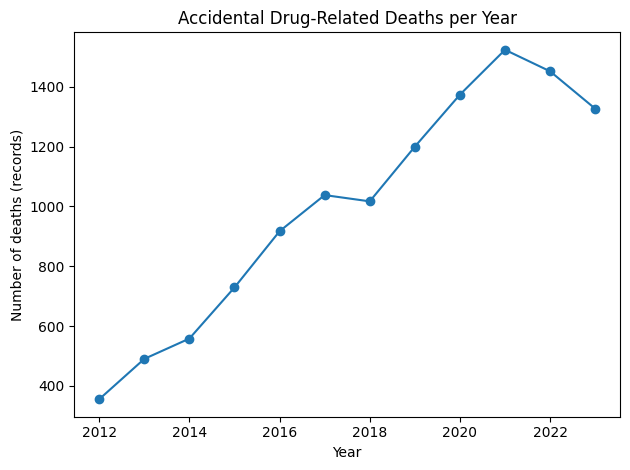

In [290]:
# Plot yearly death-record counts to visualize the overall trend over time.
year_counts = df_clean.groupby("Year").size().sort_index()

plt.figure()
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Accidental Drug-Related Deaths per Year")
plt.xlabel("Year")
plt.ylabel("Number of deaths (records)")
plt.tight_layout()
plt.show()

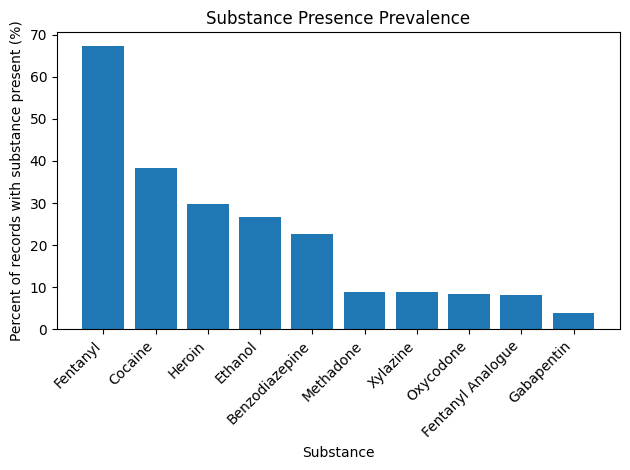

In [291]:
# Compute and plot substance prevalence across all records.
drug_cols = [
    "Fentanyl","Heroin","Cocaine","Benzodiazepine","Ethanol","Methadone",
    "Oxycodone","Xylazine","Gabapentin","Fentanyl Analogue"
]
drug_cols = [c for c in drug_cols if c in df_clean.columns]

for c in drug_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce").fillna(0).astype(int)

prev = (df_clean[drug_cols].mean() * 100).sort_values(ascending=False)

plt.figure()
plt.bar(prev.index, prev.values)
plt.title("Substance Presence Prevalence")
plt.xlabel("Substance")
plt.ylabel("Percent of records with substance present (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

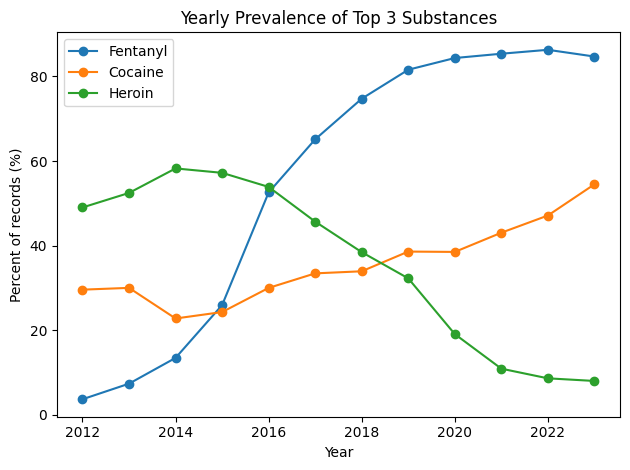

In [292]:
# Plot yearly prevalence trends for the top 3 most common substances.
top3 = prev.index[:3].tolist()
yearly_prev = df_clean.groupby("Year")[top3].mean() * 100

plt.figure()
for col in top3:
    plt.plot(yearly_prev.index, yearly_prev[col], marker="o", label=col)

plt.title("Yearly Prevalence of Top 3 Substances")
plt.xlabel("Year")
plt.ylabel("Percent of records (%)")
plt.legend()
plt.tight_layout()
plt.show()

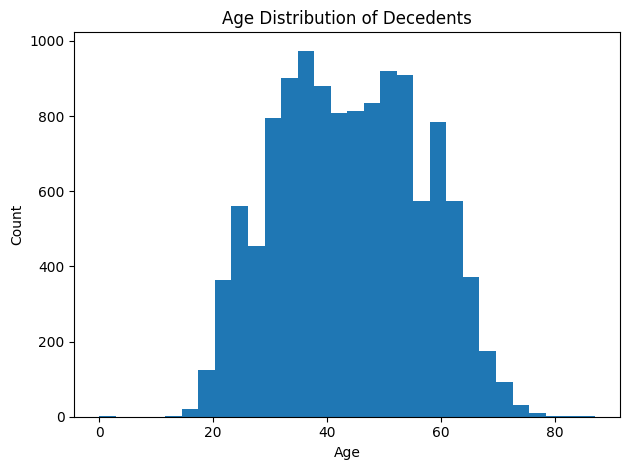

In [293]:
# Plot histogram of decedent ages to view the age distribution.
plt.figure()
plt.hist(df_clean["Age"].astype(float), bins=30)
plt.title("Age Distribution of Decedents")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

C:\Users\evanc\AppData\Local\Temp\ipykernel_22960\2575191381.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sex_order, showfliers=True)


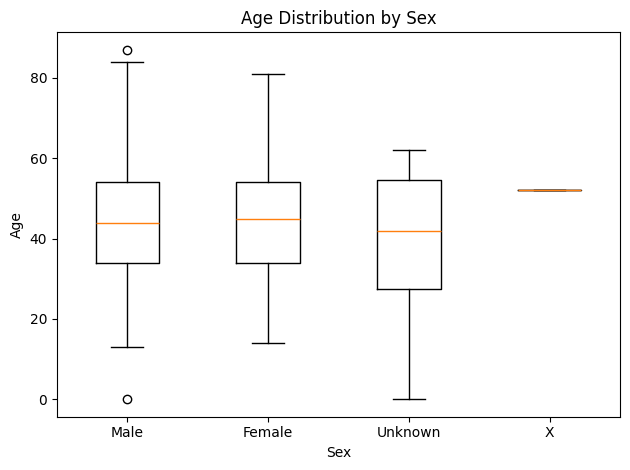

In [295]:
# Compare age distributions across sex categories using a boxplot.
sex_order = df_clean["Sex"].value_counts().index.tolist()
data = [df_clean.loc[df_clean["Sex"] == s, "Age"].astype(float).values for s in sex_order]

plt.figure()
plt.boxplot(data, labels=sex_order, showfliers=True)
plt.title("Age Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

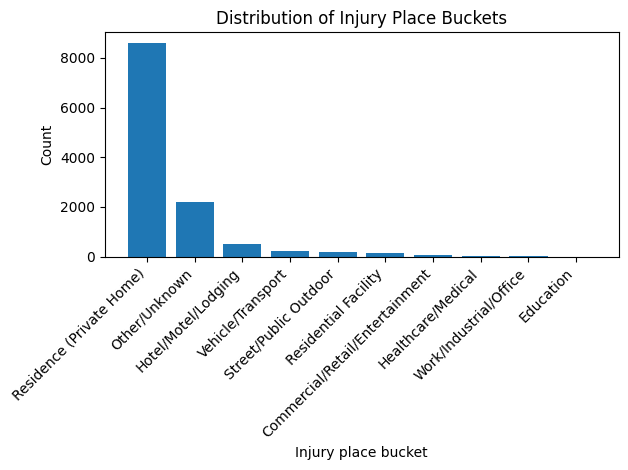

In [296]:
# Plot the distribution of standardized injury-place bucket counts.
bucket_counts = df_clean["InjuryPlace_Bucket"].value_counts()

plt.figure()
plt.bar(bucket_counts.index, bucket_counts.values)
plt.title("Distribution of Injury Place Buckets")
plt.xlabel("Injury place bucket")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

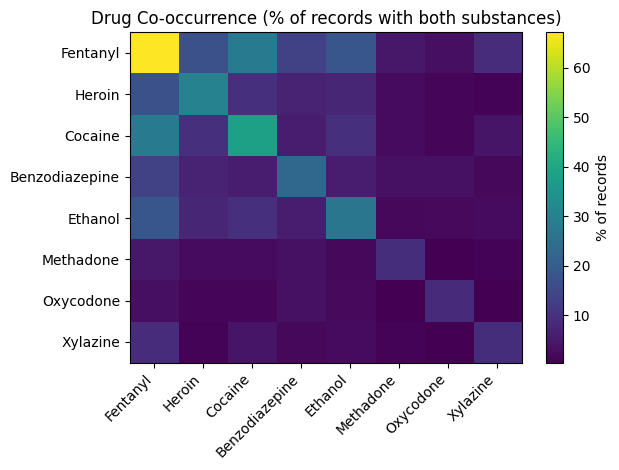

In [299]:
# Build a heatmap of pairwise drug co-occurrence percentages.
# Pick the drug columns you want in the heatmap
drug_cols = ["Fentanyl","Heroin","Cocaine","Benzodiazepine","Ethanol","Methadone","Oxycodone","Xylazine"]
drug_cols = [c for c in drug_cols if c in df_clean.columns]

# Convert to safe binary ints (NO NaN)
for c in drug_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce").fillna(0).astype("int8")

# Co-occurrence matrix (% of records where both are 1)
co = np.zeros((len(drug_cols), len(drug_cols)))
for i, a in enumerate(drug_cols):
    for j, b in enumerate(drug_cols):
        co[i, j] = ((df_clean[a] == 1) & (df_clean[b] == 1)).mean() * 100

plt.figure()
plt.imshow(co, aspect="auto")
plt.title("Drug Co-occurrence (% of records with both substances)")
plt.xticks(range(len(drug_cols)), drug_cols, rotation=45, ha="right")
plt.yticks(range(len(drug_cols)), drug_cols)
plt.colorbar(label="% of records")
plt.tight_layout()
plt.show()